Stuart Rossiter, C00284845

# Licensing
K Nearest Neighbours Classifier using the Diabetes Risk Prediction Dataset Copyright (C) 2025 Stuart Rossiter 
https://www.kaggle.com/datasets/vishardmehta/diabetes-risk-prediction-dataset

This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.

This program is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.

You should have received a copy of the GNU General Public License along with this program. If not, see https://www.gnu.org/licenses/.

# K Nearest Neighbours Classifier - Diabetes Risk Classification
Using K Nearest Neighbours, an attempt will be made to determine the risk of an individual developing diabetes. The dataset includes features such as Age, BMI, Blood Pressure, and Fasting Glucose Level. 

# Preprocessing
First things first, let's import the data from the csv using pandas, and drop the unnecessary columns.

In [38]:
import pandas as pd

data = pd.read_csv("diabetes_risk_dataset.csv")
data = data.drop(["Patient_ID", "diabetes_risk_score"], axis=1)

Next, we must encode the categorical data, such as Gender or Family History of Diabetes.

In [39]:
data["gender"] = data["gender"].map({"Male": 1, "Female": 0})
data["family_history_diabetes"] = data["family_history_diabetes"].map({"Yes": 1, "No": 0})

features = data.drop("diabetes_risk_category", axis=1)
features = pd.get_dummies(features, columns=["physical_activity_level"], drop_first=True)
category = data["diabetes_risk_category"].map({"Low Risk": 0, "High Risk": 1, "Prediabetes": 2})

With our data imported and encoded, it's ready for the train/test split.

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, category, test_size=0.3, random_state=13, stratify=category)

As with all models, scaling is necessary. This scales the data to reasonable values, so that no column holds more power than the other.

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Fitting and Predictions
Finally, we're ready to fit our model, and make some predictions. These predictions of diabetes risk will be displayed in a confusion matrix, so that we can analyze the results.

[[727   1  53]
 [  3 604  66]
 [ 68  49 229]]


Text(113.9222222222222, 0.5, 'predicted label')

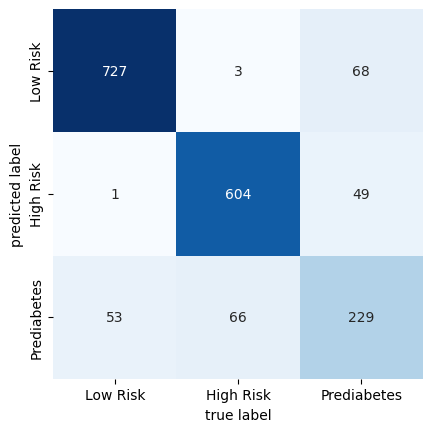

In [58]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

import sklearn.metrics as mtc
import matplotlib.pyplot as plt
import seaborn as sb

matrix = mtc.confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
print(matrix)

sb.heatmap(matrix.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=["Low Risk", "High Risk", "Prediabetes"], yticklabels=["Low Risk", "High Risk", "Prediabetes"],
            cmap='Blues')
plt.xlabel('true label')
plt.ylabel('predicted label')

# Tuning
This is a very good outcome. The model struggles a little with the Prediabetes class though. Let's see if we can fix that with some hyperparameter tuning on the KNN Classifier. We'll use SKLearn's GridSearchCV to search through some parameters, to find the best set.

In [63]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors": range(1, 11),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_diabetes = GridSearchCV(KNeighborsClassifier(), param_grid, scoring="f1_macro")

grid_diabetes.fit(X_train, y_train)
print(grid_diabetes.best_params_)

{'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'distance'}


The best permutation of the above parameters has been found, so let's try training a new model on the data with those parameters in mind. Once again, the results will be in the form of a confusion matrix.

[[737   1  43]
 [  1 594  78]
 [ 56  40 250]]


Text(113.9222222222222, 0.5, 'predicted label')

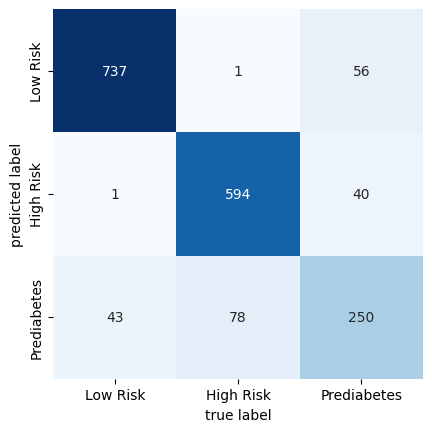

In [65]:
model = KNeighborsClassifier(n_neighbors=grid_diabetes.best_params_["n_neighbors"],
                             metric=grid_diabetes.best_params_["metric"],
                             weights=grid_diabetes.best_params_["weights"])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

matrix = mtc.confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
print(matrix)

sb.heatmap(matrix.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=["Low Risk", "High Risk", "Prediabetes"], yticklabels=["Low Risk", "High Risk", "Prediabetes"],
            cmap='Blues')
plt.xlabel('true label')
plt.ylabel('predicted label')

# Conclusion
The results of the tuning are very interesting. There was little difference in the before and after: Prediabetes and Low Risk got a bit better, and High Risk got a bit worse. These results indicate that the remaining gains lie within the improvement of the data itself, as opposed to the model.